#Exploration du jeu d'entraînement de la politique de choix modalLe jeu que `fit_mode_choice_policy.py` consomme (`progedo_mode_choice_v2.parquet`,EMC² Toulouse 2023), exporté et **rechargé en CSV**, puis passé au crible :description pandas, représentativité de chaque composant entre `train` et `test`,valeurs aberrantes, colonnes contaminées.**Trois choses à ne pas perdre de vue en lisant les chiffres.**1. **Le découpage n'est pas refait ici.** La colonne `split` du parquet est étanche au   ménage (`hh_id`). Un re-tirage local mélangerait les déplacements d'un même foyer   entre les deux côtés. Le notebook **vérifie** l'étanchéité, il ne la reconstruit pas.2. **`sample_weight` (le COEP de l'enquête) pondère tout ce qui prétend décrire la   population.** Une part modale non pondérée n'est pas représentative — chaque   distribution est donc affichée dans les deux lectures, brute et redressée.3. **`distance_km`, `crow_km` et `duration_min` sont contaminées** (ticket 005 §1) et   listées `diagnostic_only` dans le spec. Elles sont explorées ici *en tant que fuite*,   jamais comme variables candidates.**Prérequis :** `progedo_mode_choice_v2.parquet` et `feature_spec.json` sont versionnésdans le dépôt. Les données PROGEDO brutes (accès restreint lil-1750) ne sont pasnécessaires.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.autolayout": True})

# Racine du dépôt, repérée au spec (comme fit_mode_choice_policy) : le notebook doit
# tourner qu'on l'ouvre depuis scripts/progedo_logit/ ou depuis la racine.
MARKER = Path("scripts") / "progedo_logit" / "feature_spec.json"
ROOT = Path.cwd().resolve()
while not (ROOT / MARKER).exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / MARKER).exists(), "Racine du dépôt introuvable."

DATA_DIR = ROOT / "scripts" / "progedo_logit"
PARQUET = DATA_DIR / "progedo_mode_choice_v2.parquet"
SPEC = json.loads((DATA_DIR / "feature_spec.json").read_text())
CSV = {"train": DATA_DIR / "mode_choice_train.csv",
       "test": DATA_DIR / "mode_choice_test.csv"}

# Palette officielle du projet (.claude/CLAUDE.md) — identique aux notebooks, à GAMA
# et aux dashboards Grafana. Les classes de la politique en sont un sous-ensemble.
MODE_COLORS = {"car": "red", "bike": "purple", "transit": "green", "walk": "cyan"}
CLASSES = SPEC["target"]["classes"]
SPLIT_COLORS = {"train": "#4C6EF5", "test": "#F08C00"}

print(f"Racine   : {ROOT}")
print(f"Spec     : version {SPEC['spec_version']} — {len(SPEC['features'])} variables, "
      f"cible « {SPEC['target']['name'] } » sur {CLASSES}")

Racine   : /Users/yvesb/Documents/Projects/llm-agents-gama
Spec     : version 2 — 21 variables, cible « mode » sur ['bike', 'car', 'transit', 'walk']


---## 0. Export CSV, puis rechargement depuis le CSVLe parquet est la source ; les deux CSV en sont une **projection**, régénérée si ellemanque. La suite du notebook ne relit plus jamais le parquet : tout ce qui est décritci-dessous a réellement fait l'aller-retour par le CSV, arrondis et pertes de typecompris.Ces CSV sont ignorés par git (`scripts/progedo_logit/*.csv`) : ce sont des artefactsdérivés, pas des données à versionner.**Le round-trip CSV perd les types**, et c'est le piège du format : un `bool` revient en`"True"`/`"False"`, un `Int64` avec valeurs manquantes revient en `float`, et unecatégorie perd la liste de ses modalités — donc une modalité absente du `test` ne severrait pas dans un `value_counts()`. Les types sont **réimposés depuis le spec** justeaprès lecture, pas devinés.

In [2]:
def export_csv(force: bool = False) -> dict[str, Path]:
    '''Écrit train.csv / test.csv depuis le parquet. Ne réécrit pas sans `force`.'''
    if not force and all(p.exists() for p in CSV.values()):
        for name, path in CSV.items():
            print(f"[skip]  {path.name} déjà présent ({path.stat().st_size/1e6:.1f} Mo)")
        return CSV
    df = pd.read_parquet(PARQUET)
    print(f"[lu]    {PARQUET.name} : {len(df):,} lignes × {df.shape[1]} colonnes")
    for name, path in CSV.items():
        part = df[df["split"] == name]
        part.to_csv(path, index=False)
        print(f"[écrit] {path.name} : {len(part):,} lignes ({path.stat().st_size/1e6:.1f} Mo)")
    return CSV


def apply_spec_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    '''Réimpose les types du contrat de features après un aller-retour CSV.'''
    for feat in SPEC["features"]:
        col, kind = feat["name"], feat["kind"]
        if col not in df.columns:
            continue
        if kind == "bool":
            df[col] = df[col].map({"True": True, "False": False, True: True, False: False})
            df[col] = df[col].astype("boolean")
        elif kind == "categorical":
            # Catégories imposées par le spec : une modalité jamais vue dans un split
            # reste visible (effectif 0) au lieu de disparaître du tableau.
            df[col] = pd.Categorical(df[col], categories=feat["categories"])
        elif kind == "numeric":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # `same_zone` est déclaré bool dans le spec, les autres booléens hors spec suivent.
    for col in ("same_zone",):
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].map({"True": True, "False": False}).astype("boolean")
    for col in ("distance_km", "crow_km", "duration_min", "sample_weight"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


export_csv()
train = apply_spec_dtypes(pd.read_csv(CSV["train"], low_memory=False))
test = apply_spec_dtypes(pd.read_csv(CSV["test"], low_memory=False))
full = pd.concat([train, test], ignore_index=True)

FEATURES = [f["name"] for f in SPEC["features"]]
NUMERIC = [f["name"] for f in SPEC["features"] if f["kind"] == "numeric"]
CATEG = [f["name"] for f in SPEC["features"] if f["kind"] == "categorical"]
BOOLS = [f["name"] for f in SPEC["features"] if f["kind"] == "bool"]
LEAKY = SPEC["diagnostic_only"]

print(f"\ntrain {train.shape}   test {test.shape}   "
      f"({len(test)/len(full):.1%} en test, cible {SPEC['split']['test_size']:.0%})")
print(f"{len(NUMERIC)} numériques · {len(CATEG)} catégorielles · {len(BOOLS)} booléennes "
      f"· {len(LEAKY)} contaminées (hors modèle)")

[skip]  mode_choice_train.csv déjà présent (10.5 Mo)
[skip]  mode_choice_test.csv déjà présent (3.5 Mo)



train (39203, 32)   test (13045, 32)   (25.0% en test, cible 25%)
9 numériques · 6 catégorielles · 6 booléennes · 3 contaminées (hors modèle)


---## 1. La description pandasDeux tableaux, parce que `describe()` ne dit pas la même chose des deux familles :quantiles et dispersion pour le numérique, effectifs et modalité dominante pour le reste.Les colonnes contaminées sont décrites **à part** — les mélanger au reste laisseraitcroire qu'elles entrent dans le modèle.

In [3]:
desc_num = pd.concat(
    {"train": train[NUMERIC].describe().T, "test": test[NUMERIC].describe().T},
    axis=1)
desc_num

train                                                                      test                                                               
                         count      mean       std   min     25%     50%       75%        max      count      mean       std   min     25%     50%       75%        max
age                 39,203.000    43.408    21.096 5.000  25.000  43.000    60.000    100.000 13,045.000    43.285    21.384 5.000  25.000  44.000    60.000     98.000
household_size      39,203.000     2.478     1.364 1.000   1.000   2.000     4.000      8.000 13,045.000     2.429     1.318 1.000   1.000   2.000     3.000      7.000
number_of_cars      39,203.000     1.444     0.916 0.000   1.000   1.000     2.000      9.000 13,045.000     1.436     0.917 0.000   1.000   1.000     2.000      6.000
departure_hour      39,203.000    13.242     4.345 0.000   9.000  13.000    17.000     23.000 13,045.000    13.387     4.366 0.000  10.000  14.000    17.000     23.000
od_km               39,203.000     4.734     6.388 0.157   1.034   2.456     5.657     69.527 13,045.000     4.733     6.309 0.159   1.100   2.456     5.677     68.659
dist_center_orig_km 39,203.000    11.174    10.498 0.231   3.557   7.948    15.557     61.068 13,045.000    11.167    10.248 0.231   3.677   8.160    15.557     61.068
dist_center_dest_km 39,203.000    11.180    10.491 0.231   3.557   7.948    15.557     61.068 13,045.000    11.174    10.250 0.231   3.677   8.160    15.557     61.068
density_orig        38,125.000 2,575.123 3,741.533 1.936 162.075 832.167 3,645.958 19,572.364 12,676.000 2,562.701 3,774.447 4.221 159.016 794.552 3,615.956 19,572.364
density_dest        38,124.000 2,577.194 3,747.938 1.936 162.075 832.167 3,645.958 19,572.364 12,680.000 2,561.577 3,773.150 4.221 159.016 794.552 3,615.956 19,572.364

In [4]:
rows = []
for col in CATEG + BOOLS:
    for name, df in (("train", train), ("test", test)):
        s = df[col]
        vc = s.value_counts(dropna=True)
        rows.append({"variable": col, "split": name, "n": int(s.notna().sum()),
                     "manquants": int(s.isna().sum()),
                     "modalités": int(s.nunique(dropna=True)),
                     "dominante": (str(vc.index[0]) if len(vc) else "—"),
                     "part_dominante_%": (round(100 * vc.iloc[0] / vc.sum(), 1) if len(vc) else np.nan)})
pd.DataFrame(rows).pivot(index="variable", columns="split",
                         values=["n", "manquants", "modalités", "dominante", "part_dominante_%"])

n        manquants       modalités                    dominante                        part_dominante_%       
split                     test  train      test train      test train                   test                  train             test  train
variable                                                                                                                                   
car_availability         13045  39203         0     0         3     3                    all                    all           71.700 72.400
employed                 13045  39203         0     0         2     2                  False                  False           52.600 52.500
gender                   13045  39203         0     0         2     2                 Female                 Female           54.600 54.200
has_bike                 13045  39203         0     0         2     2                   True                   True           52.900 52.900
has_driving_license      13045  39203         0     0         2     2                   True                   True           76.700 77.900
has_pt_subscription      13045  39203         0     0         2     2                  False                  False           75.700 74.600
main_occupation          13045  39203         0     0         8     8  Travail à plein temps  Travail à plein temps           40.700 41.100
purpose                  13045  39203         0     0         6     6                   home                   home           40.100 39.500
purpose_origin           13045  39203         0     0         6     6                   home                   home           40.100 39.500
same_zone                13045  39203         0     0         2     2                  False                  False           73.800 74.100
socioprofessional_class  13045  39203         0     0         8     8               Employee               Employee           25.000 24.400
studies                  13045  39203         0     0         2     2                  False                  False           76.600 77.900

In [5]:
print("Colonnes CONTAMINÉES (diagnostic_only du spec) — décrites, jamais entraînées :")
display(pd.concat({"train": train[LEAKY].describe().T, "test": test[LEAKY].describe().T}, axis=1))

Colonnes CONTAMINÉES (diagnostic_only du spec) — décrites, jamais entraînées :


train                                                       test                                                
                  count   mean    std   min   25%    50%    75%     max      count   mean    std   min   25%    50%    75%     max
distance_km  39,203.000  6.620  9.107 0.001 1.000  3.000  8.562  99.925 13,045.000  6.568  8.857 0.001 1.000  3.007  8.621  80.824
crow_km      39,203.000  4.539  6.535 0.001 0.728  1.919  5.699  68.283 13,045.000  4.504  6.421 0.001 0.742  1.987  5.742  68.208
duration_min 39,203.000 18.940 19.208 1.000 7.000 15.000 25.000 480.000 13,045.000 19.059 19.602 1.000 6.000 15.000 25.000 360.000

### Valeurs manquantesUn manquant n'est pas neutre ici : LightGBM traite `NaN` comme une branche à partentière, donc une variable trouée n'échoue pas — elle apprend le trou. Il faut donc levoir.

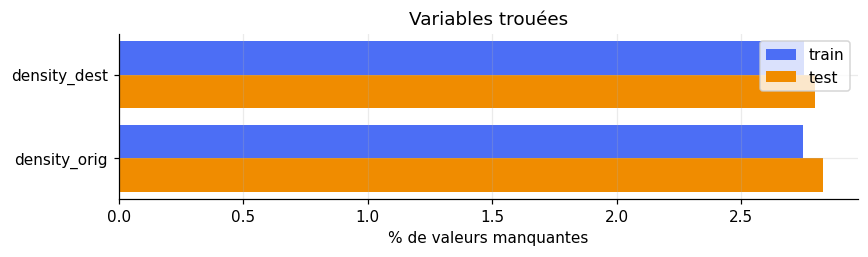

,train_%,test_%,train_n,test_n
density_dest,2.752,2.798,1079,365
density_orig,2.750,2.829,1078,369


In [6]:
miss = pd.DataFrame({
    "train_%": 100 * train[FEATURES + LEAKY].isna().mean(),
    "test_%": 100 * test[FEATURES + LEAKY].isna().mean(),
    "train_n": train[FEATURES + LEAKY].isna().sum(),
    "test_n": test[FEATURES + LEAKY].isna().sum(),
}).sort_values("train_%", ascending=False)
trous = miss[miss[["train_%", "test_%"]].max(axis=1) > 0]
if trous.empty:
    print("Aucune valeur manquante sur les variables du contrat.")
else:
    fig, ax = plt.subplots(figsize=(8, 0.42 * len(trous) + 1.6))
    y = np.arange(len(trous))
    ax.barh(y - 0.2, trous["train_%"], 0.4, label="train", color=SPLIT_COLORS["train"])
    ax.barh(y + 0.2, trous["test_%"], 0.4, label="test", color=SPLIT_COLORS["test"])
    ax.set_yticks(y, trous.index); ax.invert_yaxis(); ax.legend()
    ax.set_xlabel("% de valeurs manquantes"); ax.set_title("Variables trouées")
    plt.show()
display(trous)

---## 2. La cible, brute et redressée`sample_weight` est le coefficient de redressement de l'enquête. Sans lui, les partsmodales décrivent l'échantillon, pas l'agglomération — et c'est la population que lemodèle doit reproduire. L'écart entre les deux colonnes ci-dessous est exactement ce quele redressement corrige.

,train brut,train redressé,test brut,test redressé
mode,,,,
bike,4.030,4.260,3.980,4.010
car,55.120,55.420,56.040,57.070
transit,11.900,12.150,12.360,12.640
walk,28.950,28.170,27.630,26.280
— effectif —,"39,203.000","3,360,166.790","13,045.000","1,107,051.450"


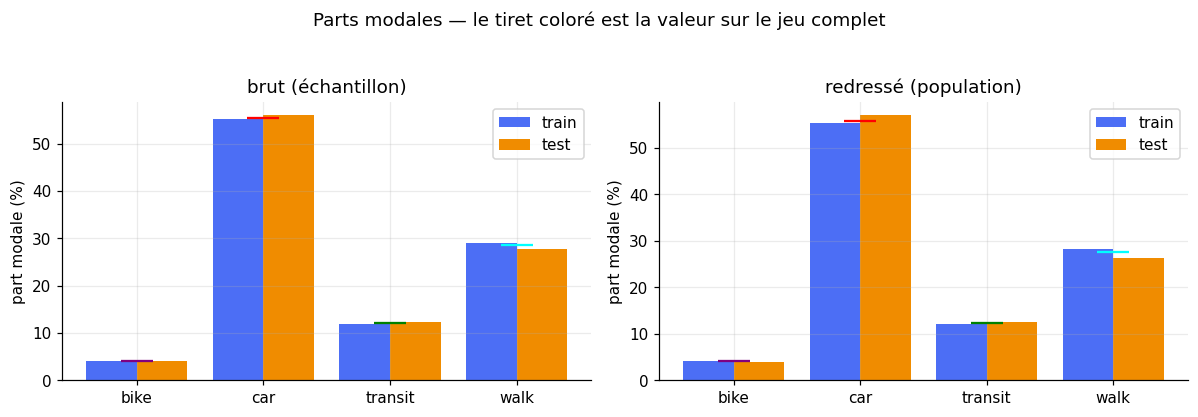

In [7]:
def shares(df: pd.DataFrame, weighted: bool) -> pd.Series:
    w = df["sample_weight"] if weighted else pd.Series(1.0, index=df.index)
    s = w.groupby(df["mode"]).sum()
    return (100 * s / s.sum()).reindex(CLASSES).fillna(0.0)

tab = pd.DataFrame({
    "train brut": shares(train, False), "train redressé": shares(train, True),
    "test brut": shares(test, False), "test redressé": shares(test, True),
})
tab.loc["— effectif —"] = [len(train), train["sample_weight"].sum(),
                           len(test), test["sample_weight"].sum()]
display(tab.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, weighted, titre in zip(axes, (False, True), ("brut (échantillon)", "redressé (population)")):
    x = np.arange(len(CLASSES))
    ax.bar(x - 0.2, shares(train, weighted), 0.4, label="train", color=SPLIT_COLORS["train"])
    ax.bar(x + 0.2, shares(test, weighted), 0.4, label="test", color=SPLIT_COLORS["test"])
    for i, c in enumerate(CLASSES):
        ax.scatter([i], [shares(full, weighted)[c]], marker="_", s=420, color=MODE_COLORS[c], zorder=3)
    ax.set_xticks(x, CLASSES); ax.set_ylabel("part modale (%)"); ax.set_title(titre); ax.legend()
fig.suptitle("Parts modales — le tiret coloré est la valeur sur le jeu complet", y=1.04)
plt.show()

### Déséquilibre de classes`bike` est la classe rare. C'est une propriété de la réalité mesurée, pas un défaut àcorriger : le ticket 005 (décision E7) écarte explicitement `is_unbalance` et`class_weight`, parce que rééquilibrer détruit la calibration des probabilités — or cesont les **probabilités**, pas l'accuracy, qui servent à produire des parts modales.

In [8]:
n = full.groupby("mode", observed=True).size().reindex(CLASSES)
w = full.groupby("mode", observed=True)["sample_weight"].sum().reindex(CLASSES)
display(pd.DataFrame({"n": n, "part brute %": 100*n/n.sum(),
                      "part redressée %": 100*w/w.sum(),
                      "ratio à la classe majoritaire": (n.max()/n).round(1)}))

,n,part brute %,part redressée %,ratio à la classe majoritaire
mode,,,,
bike,2100,4.019,4.197,13.800
car,28918,55.348,55.830,1.000
transit,6277,12.014,12.272,4.600
walk,14953,28.619,27.701,1.900


---## 3. Intégrité du découpageLe seul contrôle qui compte : **aucun ménage ne doit se trouver des deux côtés**. Unménage à cheval, et le modèle voit à l'entraînement les déplacements des personnes qu'ilsera noté à prédire — l'accuracy de test cesse d'être un chiffre de généralisation.

In [9]:
hh_tr, hh_te = set(train["hh_id"]), set(test["hh_id"])
fuite = hh_tr & hh_te
print(f"Ménages train : {len(hh_tr):,}   test : {len(hh_te):,}   à cheval : {len(fuite)}")
print("✅ découpage étanche au ménage" if not fuite
      else f"🚨 [ALARME] {len(fuite)} ménages des deux côtés : {sorted(fuite)[:10]}")

def pid(df): return df["hh_id"].astype(str) + "/" + df["PER"].astype(str)
print(f"Personnes train : {pid(train).nunique():,}   test : {pid(test).nunique():,}   "
      f"à cheval : {len(set(pid(train)) & set(pid(test)))}")

taille = full.groupby("split")["hh_id"].value_counts().rename("déplacements par ménage")
display(taille.groupby("split").describe().round(2))

Ménages train : 7,044   test : 2,349   à cheval : 0
✅ découpage étanche au ménage
Personnes train : 10,160   test : 3,351   à cheval : 0


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,"2,349.000",5.550,3.970,1.000,3.000,4.000,7.000,35.000
train,"7,044.000",5.570,4.010,1.000,3.000,4.000,7.000,38.000


---## 4. Représentativité de chaque composantLe découpage est tiré par ménage, pas stratifié : rien ne garantit *a priori* que chaquevariable se retrouve dans les mêmes proportions des deux côtés. On mesure donc l'écarttrain↔test variable par variable, avec une grandeur comparable d'une variable à l'autre :- **numérique** → *SMD* (différence standardisée des moyennes), l'écart en nombre  d'écarts-types. Seuils d'usage : `< 0,1` négligeable, `> 0,25` à regarder ;- **catégorielle / booléenne** → *TVD* (distance en variation totale, la moitié de la L1  entre les deux distributions de modalités), exprimée en points de %.Ces deux grandeurs ne sont pas sur la même échelle et **ne se comparent pas entrefamilles** — elles se lisent chacune contre son propre seuil. D'où deux graphiques etnon un classement unique.

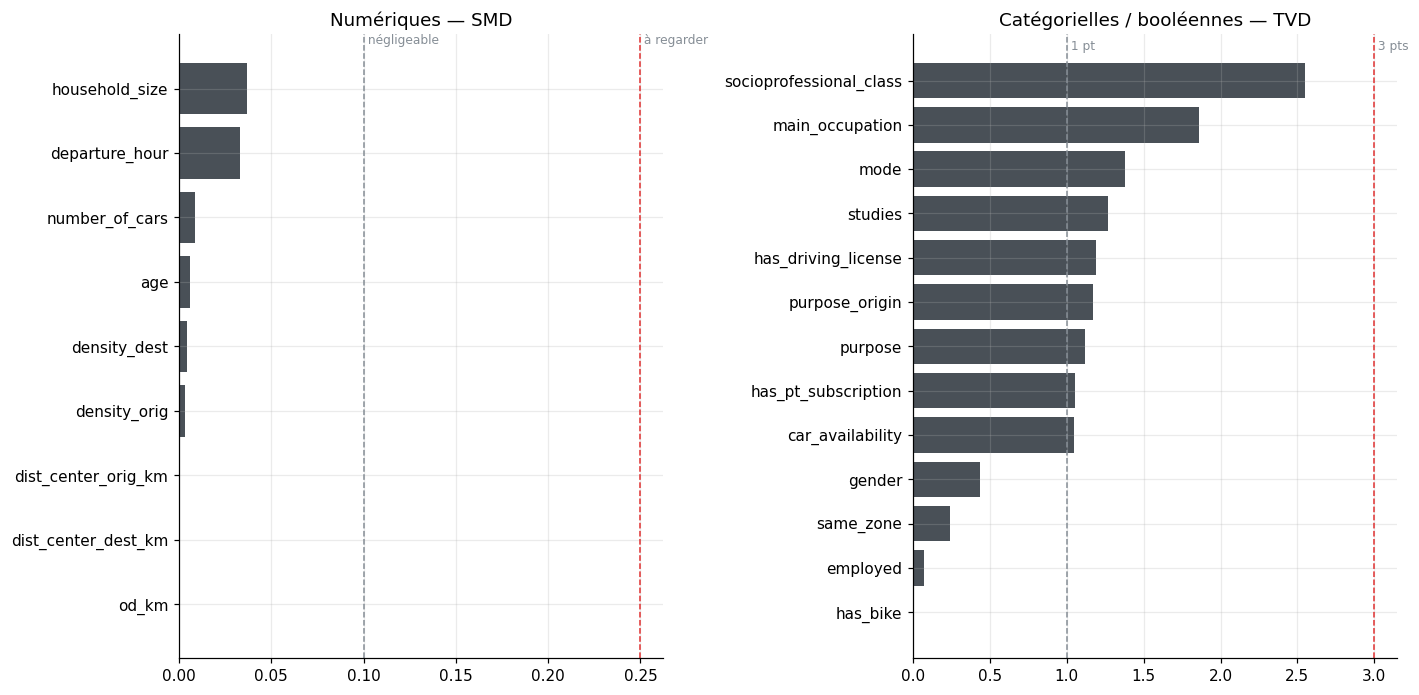

,SMD,train_moy,test_moy
household_size,0.037,2.478,2.429
departure_hour,0.033,13.242,13.387
number_of_cars,0.009,1.444,1.436
age,0.006,43.408,43.285
density_dest,0.004,"2,577.194","2,561.577"
density_orig,0.003,"2,575.123","2,562.701"
dist_center_orig_km,0.001,11.174,11.167
dist_center_dest_km,0.001,11.180,11.174
od_km,0.000,4.734,4.733


,TVD (pts de %)
socioprofessional_class,2.550
main_occupation,1.860
mode,1.380
studies,1.270
has_driving_license,1.190
purpose_origin,1.170
purpose,1.120
has_pt_subscription,1.050
car_availability,1.050
gender,0.440


✅ aucun composant hors seuil : train et test décrivent la même population.


In [10]:
def smd(a: pd.Series, b: pd.Series) -> float:
    a, b = a.dropna().astype(float), b.dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return np.nan if pooled == 0 else abs(a.mean() - b.mean()) / pooled

def tvd(a: pd.Series, b: pd.Series) -> float:
    pa = a.value_counts(normalize=True, dropna=False)
    pb = b.value_counts(normalize=True, dropna=False)
    idx = pa.index.union(pb.index)
    return 100 * 0.5 * float(np.abs(pa.reindex(idx).fillna(0) - pb.reindex(idx).fillna(0)).sum())

rep_num = (pd.Series({c: smd(train[c], test[c]) for c in NUMERIC}, name="SMD")
           .sort_values(ascending=False).to_frame())
rep_num["train_moy"] = [train[c].mean() for c in rep_num.index]
rep_num["test_moy"] = [test[c].mean() for c in rep_num.index]
rep_cat = (pd.Series({c: tvd(train[c], test[c]) for c in CATEG + BOOLS + ["mode"]},
                     name="TVD (pts de %)").sort_values(ascending=False).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 0.34 * max(len(rep_num), len(rep_cat)) + 2))
for ax, tab, seuils, titre in (
        (axes[0], rep_num["SMD"], [(0.1, "négligeable"), (0.25, "à regarder")], "Numériques — SMD"),
        (axes[1], rep_cat["TVD (pts de %)"], [(1.0, "1 pt"), (3.0, "3 pts")], "Catégorielles / booléennes — TVD")):
    y = np.arange(len(tab))
    ax.barh(y, tab.values, color="#495057")
    ax.set_yticks(y, tab.index); ax.invert_yaxis(); ax.set_title(titre)
    for s, lab in seuils:
        ax.axvline(s, ls="--", lw=1, color="#E03131" if lab.startswith("à") or "3" in lab else "#868E96")
        ax.text(s, -0.7, f" {lab}", fontsize=8, color="#868E96")
plt.show()

display(rep_num.round(3)); display(rep_cat.round(2))
alertes = list(rep_num[rep_num["SMD"] > 0.25].index) + list(rep_cat[rep_cat.iloc[:, 0] > 3].index)
print("✅ aucun composant hors seuil : train et test décrivent la même population."
      if not alertes else f"⚠ composants hors seuil : {alertes}")

### Distribution de chaque variable numérique, train contre testLes deux courbes doivent se superposer. Une bosse présente d'un seul côté est un défautde représentativité que le SMD, qui ne compare que des moyennes, peut manquer.

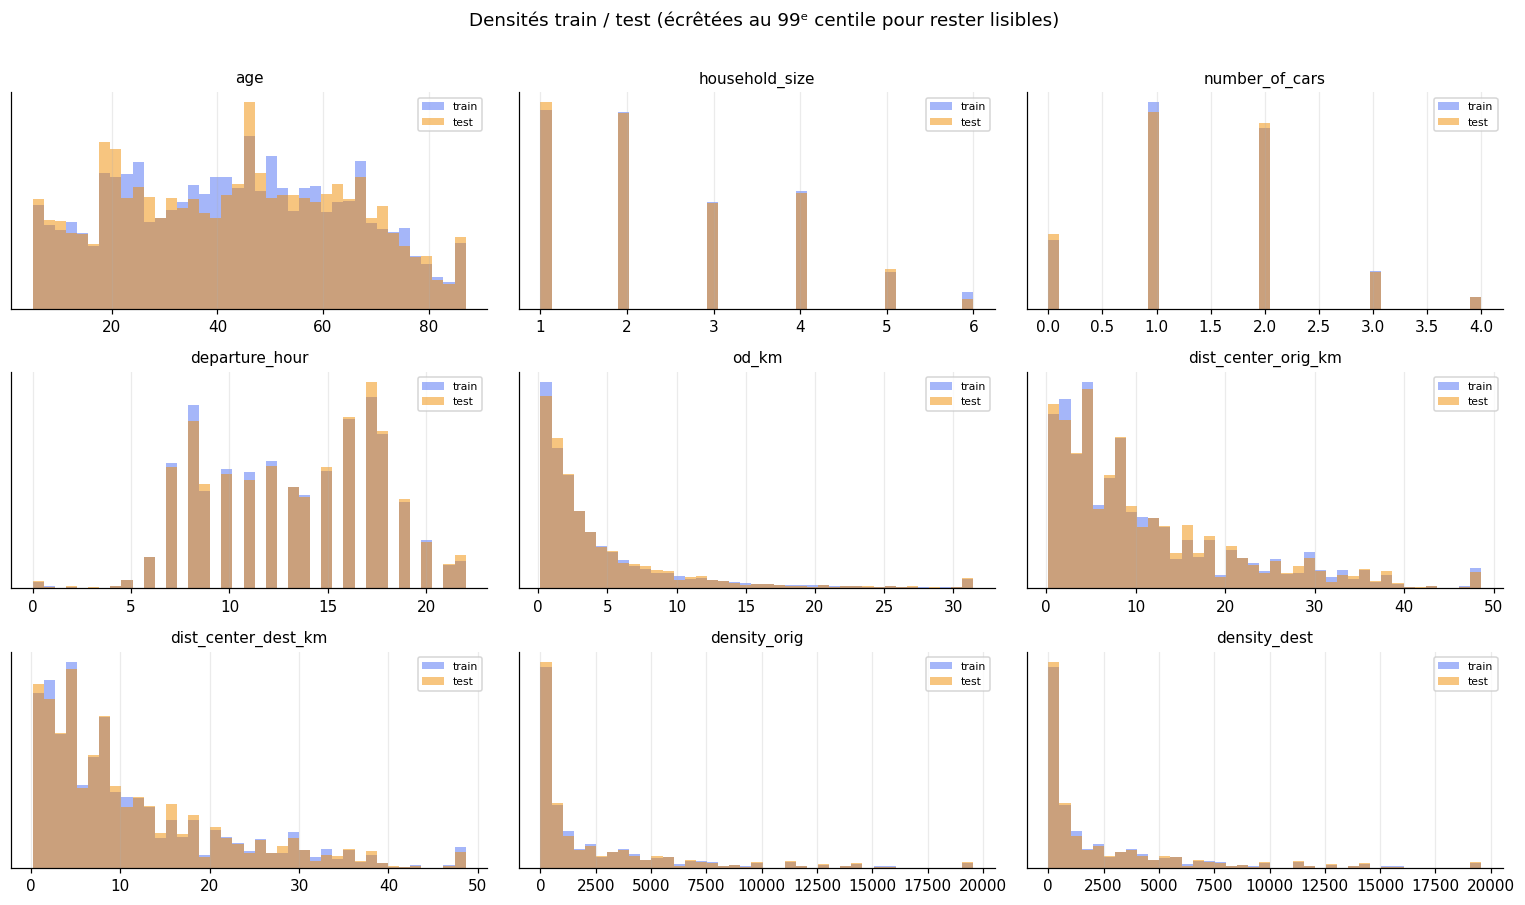

In [11]:
cols = NUMERIC
fig, axes = plt.subplots((len(cols) + 2) // 3, 3, figsize=(14, 2.7 * ((len(cols) + 2) // 3)))
for ax, col in zip(axes.ravel(), cols):
    lo, hi = np.nanpercentile(full[col].astype(float), [0, 99])
    bins = np.linspace(lo, hi if hi > lo else lo + 1, 40)
    for name, df in (("train", train), ("test", test)):
        ax.hist(df[col].astype(float).clip(lo, hi), bins=bins, density=True, alpha=0.5,
                label=name, color=SPLIT_COLORS[name])
    ax.set_title(col, fontsize=10); ax.set_yticks([])
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(cols):]:
    ax.axis("off")
fig.suptitle("Densités train / test (écrêtées au 99ᵉ centile pour rester lisibles)", y=1.01)
plt.show()

### Chaque modalité catégorielle et sa représentativité dans le testDeux informations par variable : la composition des deux splits (barres), et la **partque le test représente pour chaque modalité** (points). Cette seconde lecture est cellequi repère une modalité sous-testée : une catégorie à 25 % de test est normale, unecatégorie à 5 % est un effectif de test trop mince pour que son score veuille direquelque chose.

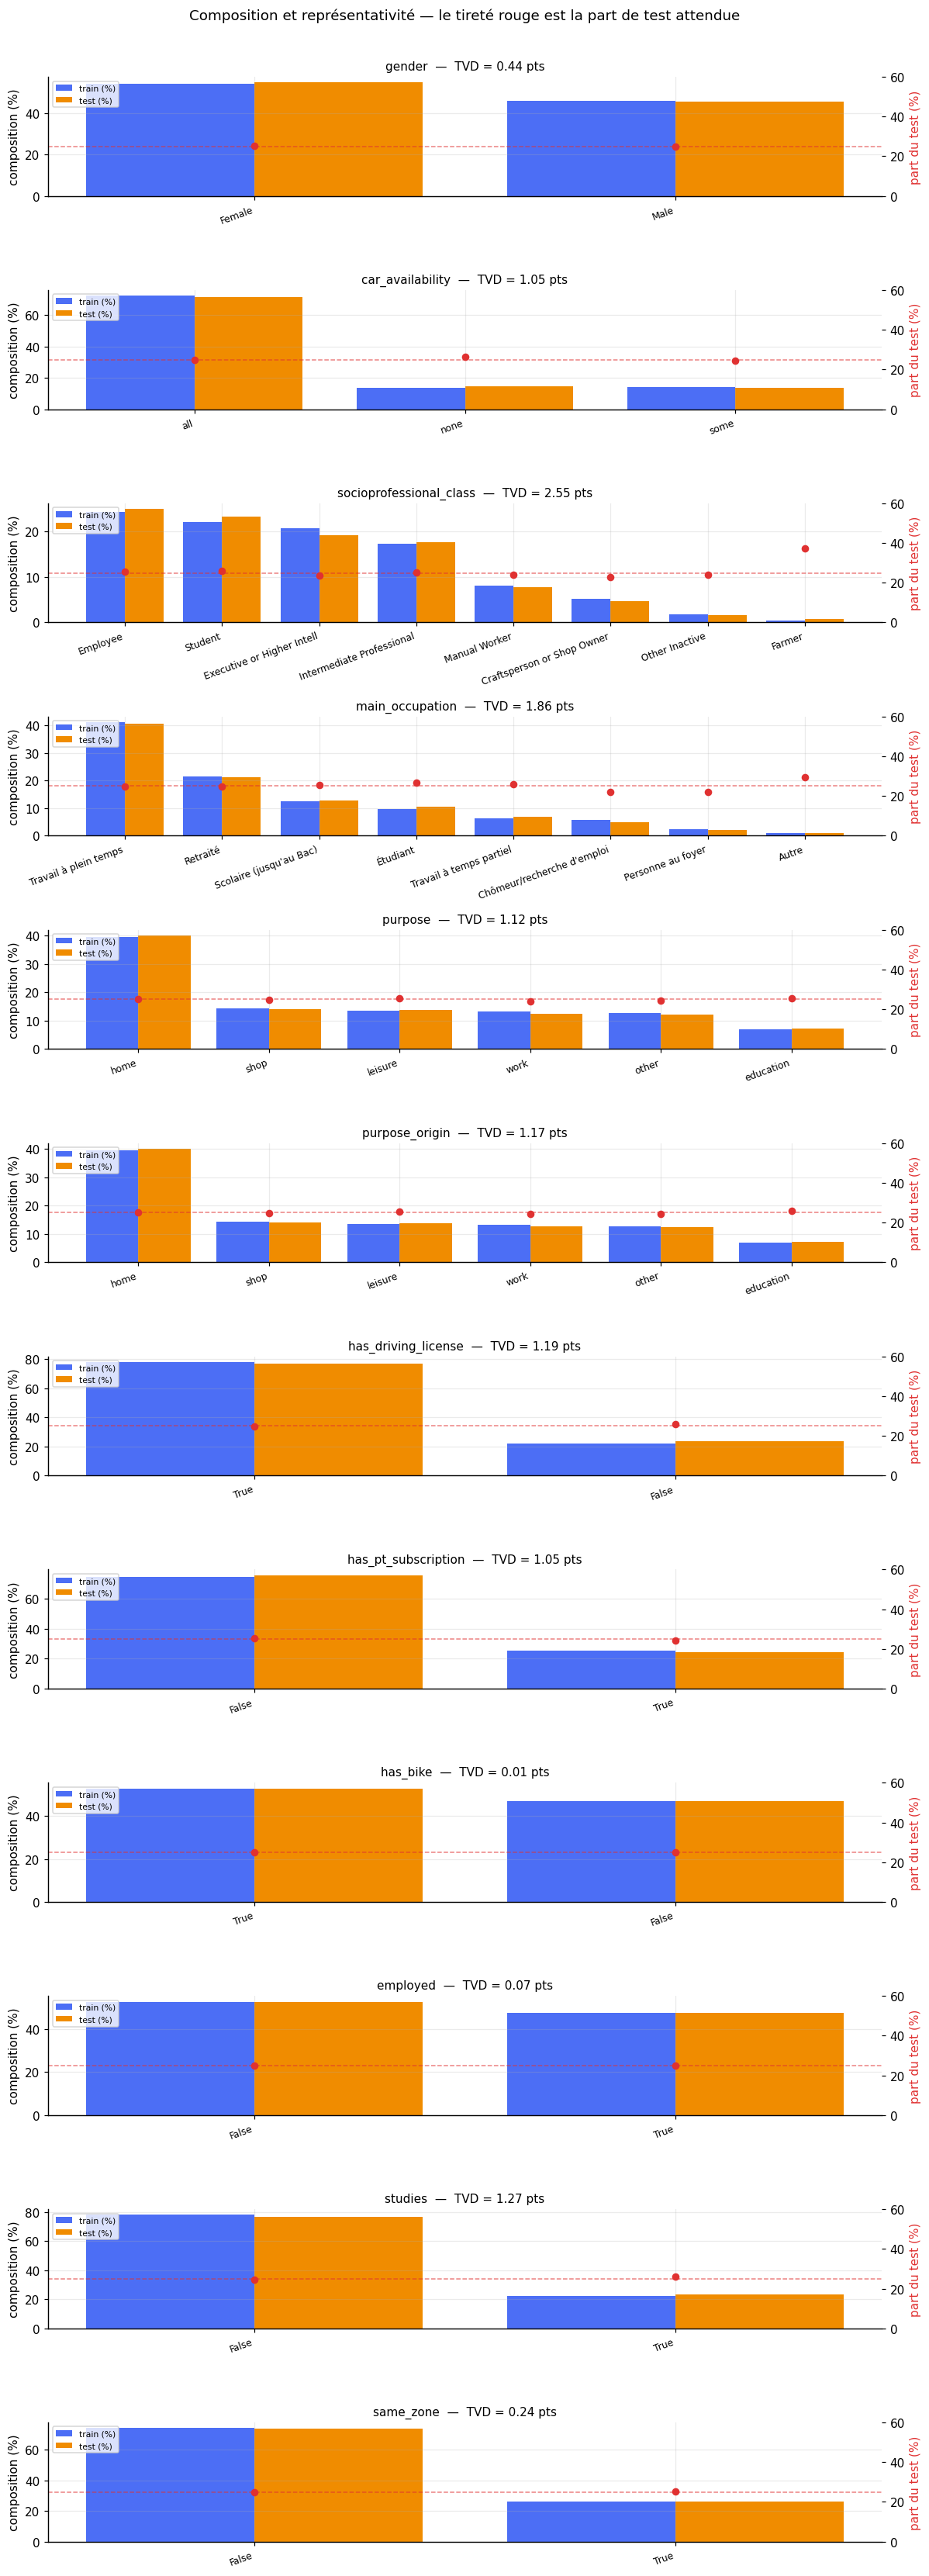

In [12]:
cols = CATEG + BOOLS
fig, axes = plt.subplots(len(cols), 1, figsize=(11, 2.5 * len(cols)))
for ax, col in zip(np.atleast_1d(axes), cols):
    ptr = train[col].value_counts(normalize=True, dropna=False).mul(100)
    pte = test[col].value_counts(normalize=True, dropna=False).mul(100)
    idx = ptr.index.union(pte.index)
    ptr, pte = ptr.reindex(idx).fillna(0), pte.reindex(idx).fillna(0)
    ntr = train[col].value_counts(dropna=False).reindex(idx).fillna(0)
    nte = test[col].value_counts(dropna=False).reindex(idx).fillna(0)
    part_test = 100 * nte / (ntr + nte).replace(0, np.nan)

    x = np.arange(len(idx))
    ax.bar(x - 0.2, ptr, 0.4, label="train (%)", color=SPLIT_COLORS["train"])
    ax.bar(x + 0.2, pte, 0.4, label="test (%)", color=SPLIT_COLORS["test"])
    ax.set_xticks(x, [str(v)[:26] for v in idx], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("composition (%)"); ax.set_title(f"{col}  —  TVD = {tvd(train[col], test[col]):.2f} pts", fontsize=10)

    ax2 = ax.twinx(); ax2.grid(False)
    ax2.scatter(x, part_test, color="#E03131", zorder=3, s=28, label="part du test (%)")
    ax2.axhline(100 * len(test) / len(full), ls="--", lw=1, color="#E03131", alpha=0.6)
    ax2.set_ylim(0, 60); ax2.set_ylabel("part du test (%)", color="#E03131")
    for xi, (v, e) in enumerate(zip(part_test, nte)):
        if e < 30:
            ax2.annotate(f"n={int(e)}", (xi, v), textcoords="offset points", xytext=(0, 7),
                         fontsize=7, color="#E03131", ha="center")
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Composition et représentativité — le tireté rouge est la part de test attendue", y=1.005)
plt.show()

---## 5. Valeurs aberrantesTrois lectures qui ne détectent pas la même chose, et aucune ne suffit seule :- **la règle IQR** (hors de `[Q1 − 1,5·IQR ; Q3 + 1,5·IQR]`) trouve les queues épaisses.  Sur une variable très asymétrique comme `od_km` elle marque une grosse minorité de  points qui ne sont pas des erreurs — un long trajet est un trajet, pas une aberration ;- **le z-score** (`|z| > 4`) trouve les points isolés, pas les queues ;- **les règles de domaine** trouvent ce que les deux précédentes ne verront jamais : une  valeur parfaitement centrale mais **impossible**. C'est la seule des trois qui distingue  une donnée fausse d'une donnée rare.

In [13]:
rows = []
for col in NUMERIC + LEAKY:
    s = full[col].astype(float).dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = (s - s.mean()) / (s.std(ddof=0) or np.nan)
    rows.append({"variable": col, "n": len(s), "min": s.min(), "p1": s.quantile(.01),
                 "médiane": s.median(), "p99": s.quantile(.99), "max": s.max(),
                 "asym.": s.skew(), "borne_bas": lo, "borne_haut": hi,
                 "IQR_%": 100 * ((s < lo) | (s > hi)).mean(),
                 "|z|>4_n": int((z.abs() > 4).sum()),
                 "contaminée": col in LEAKY})
out = pd.DataFrame(rows).set_index("variable")
display(out.round(2))

,n,min,p1,médiane,p99,max,asym.,borne_bas,borne_haut,IQR_%,|z|>4_n,contaminée
variable,,,,,,,,,,,,
age,52248,5.000,6.000,43.500,87.000,100.000,0.070,-27.500,112.500,0.000,0,False
household_size,52248,1.000,1.000,2.000,6.000,8.000,0.740,-3.500,8.500,0.000,84,False
number_of_cars,52248,0.000,0.000,1.000,4.000,9.000,0.550,-0.500,3.500,2.290,21,False
departure_hour,52248,0.000,5.000,14.000,22.000,23.000,-0.120,-0.500,27.500,0.000,0,False
od_km,52248,0.160,0.210,2.460,31.460,69.530,3.290,-5.860,12.580,8.660,611,False
dist_center_orig_km,52248,0.230,0.320,8.000,48.620,61.070,1.500,-14.240,33.430,4.650,189,False
dist_center_dest_km,52248,0.230,0.320,8.000,48.620,61.070,1.500,-14.240,33.430,4.630,187,False
density_orig,50801,1.940,13.140,821.880,"19,572.360","19,572.360",2.230,"-5,065.250","8,872.680",7.450,554,False
density_dest,50804,1.940,13.140,821.880,"19,572.360","19,572.360",2.230,"-5,065.250","8,872.680",7.470,555,False


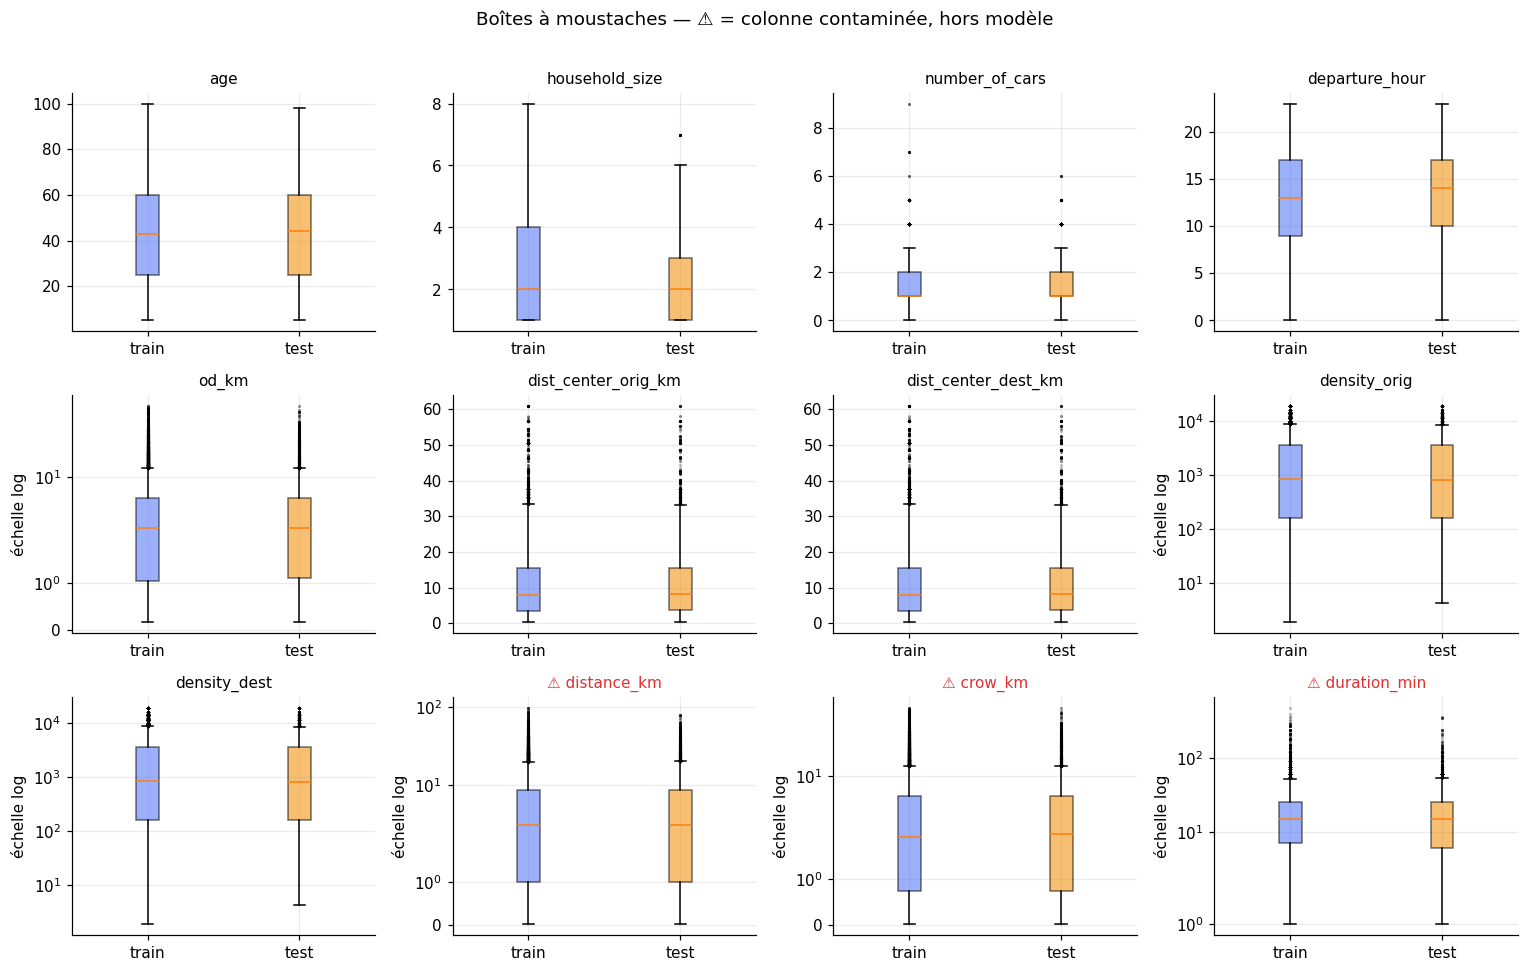

In [14]:
cols = NUMERIC + LEAKY
fig, axes = plt.subplots((len(cols) + 3) // 4, 4, figsize=(14, 2.9 * ((len(cols) + 3) // 4)))
for ax, col in zip(axes.ravel(), cols):
    data = [train[col].astype(float).dropna(), test[col].astype(float).dropna()]
    bp = ax.boxplot(data, tick_labels=["train", "test"], showfliers=True, patch_artist=True,
                    flierprops=dict(marker=".", markersize=2, alpha=0.25))
    for patch, name in zip(bp["boxes"], ("train", "test")):
        patch.set_facecolor(SPLIT_COLORS[name]); patch.set_alpha(0.55)
    ax.set_title(("⚠ " if col in LEAKY else "") + col, fontsize=10,
                 color=("#E03131" if col in LEAKY else "black"))
    if full[col].astype(float).min() >= 0 and full[col].astype(float).skew() > 2:
        ax.set_yscale("symlog"); ax.set_ylabel("échelle log")
for ax in axes.ravel()[len(cols):]:
    ax.axis("off")
fig.suptitle("Boîtes à moustaches — ⚠ = colonne contaminée, hors modèle", y=1.01)
plt.show()

In [15]:
ID = ["hh_id", "PER", "NDEP", "mode", "split"]
for col in ["od_km", "dist_center_orig_km", "dist_center_dest_km", "density_orig",
            "density_dest", "age", "household_size", "number_of_cars", "departure_hour"]:
    s = full[col].astype(float)
    extremes = full.loc[s.sort_values(ascending=False).head(5).index, ID + [col]]
    print(f"\n─── {col} — 5 valeurs les plus hautes "
          f"(médiane {s.median():,.2f}, p99 {s.quantile(.99):,.2f}) ───")
    print(extremes.to_string(index=False))


─── od_km — 5 valeurs les plus hautes (médiane 2.46, p99 31.46) ───
          hh_id  PER  NDEP mode split  od_km
411116000_10055    1     1  car train 69.527
411116000_10055    1     2  car train 69.527
405104000_10013    1     2  car train 69.024
405104000_10013    2     2  car train 69.024
411115000_20603    2     2  car  test 68.659

─── dist_center_orig_km — 5 valeurs les plus hautes (médiane 8.00, p99 48.62) ───
          hh_id  PER  NDEP mode split  dist_center_orig_km
115106000_10002    1     2  car train               61.068
411115000_20603    2     1  car  test               61.068
411115000_20534    2     1  car  test               61.068
412121000_10054    1     1  car train               61.068
411115000_20722    2     1 walk train               61.068

─── dist_center_dest_km — 5 valeurs les plus hautes (médiane 8.00, p99 48.62) ───
          hh_id  PER  NDEP mode split  dist_center_dest_km
411115000_10040    1     2  car train               61.068
411115000_10026    2   

### Saturation : la valeur la plus fréquente de chaque variableUn test que ni l'IQR ni le z-score ne font : repérer une **valeur qui revient tropsouvent**. C'est la signature d'une imputation par défaut, d'un écrêtage, ou d'un champnon renseigné rempli par une constante — un défaut qui se cache au centre de ladistribution, là où aucune détection de queue ne va regarder.Deux repères de lecture, sans lesquels le test crie au loup :- une variable **discrète** (`age`, `number_of_cars`, `household_size`, `departure_hour`)  a forcément une valeur dominante — le test n'y veut rien dire ;- `dist_center_*` et `density_*` sont des attributs **de zone fine**, pas de déplacement :  785 zones pour 52 248 déplacements, la répétition y est mécanique.Le test ne se déclenche donc que sur les variables **continues et propres au déplacement**.

In [16]:
DISCRETES = {"age", "household_size", "number_of_cars", "departure_hour"}
ZONALES = {"dist_center_orig_km", "dist_center_dest_km", "density_orig", "density_dest"}

rows = []
for col in NUMERIC + LEAKY:
    s = full[col].dropna()
    vc = s.value_counts()
    nature = ("discrète" if col in DISCRETES
              else "attribut de zone" if col in ZONALES else "continue")
    rows.append({"variable": col, "nature": nature,
                 "valeur_dominante": vc.index[0], "n": int(vc.iloc[0]),
                 "% du jeu": round(100 * vc.iloc[0] / len(s), 2),
                 "valeurs distinctes": int(s.nunique()),
                 "contaminée": col in LEAKY, "testée": nature == "continue"})
sat = pd.DataFrame(rows).set_index("variable").sort_values(["testée", "% du jeu"], ascending=False)
display(sat)

suspect = sat[sat["testée"] & (sat["% du jeu"] > 5)]
if suspect.empty:
    print("✅ aucune constante suspecte sur les variables continues")
else:
    print(f"⚠ valeur dominante > 5 % : {list(suspect.index)}")
    print(f"   dont contaminées (déjà hors modèle) : {list(suspect[suspect['contaminée']].index)}")
    print(f"   dont RETENUES par le modèle          : {list(suspect[~suspect['contaminée']].index) or '—'}")

,nature,valeur_dominante,n,% du jeu,valeurs distinctes,contaminée,testée
variable,,,,,,,
duration_min,continue,10.000,9214,17.640,138,True,True
distance_km,continue,0.333,3474,6.650,15088,True,True
crow_km,continue,0.290,3462,6.630,10477,True,True
od_km,continue,0.637,202,0.390,13002,False,True
number_of_cars,discrète,1.000,21095,40.370,9,False,False
household_size,discrète,1.000,15605,29.870,8,False,False
departure_hour,discrète,17.000,5554,10.630,24,False,False
age,discrète,36.000,996,1.910,95,False,False
density_orig,attribut de zone,"4,007.445",592,1.170,688,False,False


⚠ valeur dominante > 5 % : ['duration_min', 'distance_km', 'crow_km']
   dont contaminées (déjà hors modèle) : ['duration_min', 'distance_km', 'crow_km']
   dont RETENUES par le modèle          : —


### Règles de domaineDeux tableaux, et le partage entre eux est le point : confondre *impossible* et*invraisemblable* fait soit crier au loup sur des lignes correctes, soit laisser passerdes lignes fausses au milieu du bruit.- **A. Impossibilités** — la ligne ne peut pas exister. Tout effectif non nul est un bug  à corriger en amont (`build_mode_choice_dataset.py` ou la source), jamais une ligne à  écrêter ici.- **B. Invraisemblances** — la ligne est rare mais **peut** être vraie. On ne la corrige  pas : on vérifie que son volume reste dans l'ordre de grandeur attendu et on écrit  l'explication à côté. Une invraisemblance qui gonfle est le vrai signal.

In [17]:
DRIVING_AGE = 18
OD_KM_INTRA_MAX = 6.0   # la convention intra-zone du spec est 0.5*sqrt(SURF_M2)/1000 :
                        # elle est bornée par la taille des zones fines de l'enquête.

IMPOSSIBLE = {
    "permis avant l'âge légal": (full["has_driving_license"].fillna(False)) & (full["age"] < DRIVING_AGE),
    "âge hors [0, 110]": (full["age"] < 0) | (full["age"] > 110),
    "od_km négatif ou nul": full["od_km"] <= 0,
    "od_km intra-zone > %.0f km (convention du spec dépassée)" % OD_KM_INTRA_MAX:
        (full["same_zone"].fillna(False)) & (full["od_km"] > OD_KM_INTRA_MAX),
    "heure de départ hors [0, 23]": (full["departure_hour"] < 0) | (full["departure_hour"] > 23),
    "taille de ménage < 1": full["household_size"] < 1,
    "densité négative": (full["density_orig"] < 0) | (full["density_dest"] < 0),
    "poids de redressement ≤ 0": full["sample_weight"] <= 0,
    "durée déclarée ≤ 0": full["duration_min"] <= 0,
    "mode hors des 4 classes": ~full["mode"].isin(CLASSES),
}
INVRAISEMBLABLE = {
    "7 voitures ou plus au foyer":
        (full["number_of_cars"] >= 7, "déclaré tel quel dans l'enquête ; à surveiller, pas à corriger"),
    "« car » sans permis ni voiture au foyer":
        ((full["mode"] == "car") & (~full["has_driving_license"].fillna(False))
         & (full["number_of_cars"].fillna(0) == 0),
         "passager du véhicule d'un tiers — la cible est le mode du DÉPLACEMENT, pas la conduite"),
    "« bike » sans vélo nominatif":
        ((full["mode"] == "bike") & (~full["has_bike"].fillna(False)),
         "vélo partagé ou emprunté ; has_bike est l'attribution nominative du ticket 015"),
    "trajet de plus de 50 km":
        (full["od_km"] > 50, "périmètre d'enquête étiré, effectif très mince — cf. section 7"),
}

def table(masques):
    t = pd.DataFrame({"n": {k: int(v.fillna(False).sum()) for k, v in masques.items()}})
    t["%"] = (100 * t["n"] / len(full)).round(3)
    return t

impo = table(IMPOSSIBLE)
impo["verdict"] = np.where(impo["n"] == 0, "✅", "🚨 [ALARME] bug amont")
print("A. IMPOSSIBILITÉS — tout effectif non nul est un bug")
display(impo)

invr = table({k: v[0] for k, v in INVRAISEMBLABLE.items()})
invr["explication"] = [INVRAISEMBLABLE[k][1] for k in invr.index]
print("\nB. INVRAISEMBLANCES — attendues non nulles, on regarde le volume")
display(invr)

for nom, masque in IMPOSSIBLE.items():
    m = masque.fillna(False)
    if m.any():
        print(f"\n🚨 {nom} — {int(m.sum())} lignes, 5 exemples :")
        print(full.loc[m, ID + ["age", "has_driving_license", "number_of_cars", "has_bike",
                                "od_km", "same_zone", "duration_min"]].head(5).to_string(index=False))

A. IMPOSSIBILITÉS — tout effectif non nul est un bug


,n,%,verdict
permis avant l'âge légal,0,0.000,✅
"âge hors [0, 110]",0,0.000,✅
od_km négatif ou nul,0,0.000,✅
od_km intra-zone > 6 km (convention du spec dépassée),0,0.000,✅
"heure de départ hors [0, 23]",0,0.000,✅
taille de ménage < 1,0,0.000,✅
densité négative,0,0.000,✅
poids de redressement ≤ 0,0,0.000,✅
durée déclarée ≤ 0,0,0.000,✅
mode hors des 4 classes,0,0.000,✅



B. INVRAISEMBLANCES — attendues non nulles, on regarde le volume


,n,%,explication
7 voitures ou plus au foyer,12,0.023,déclaré tel quel dans l'enquête ; à surveiller...
« car » sans permis ni voiture au foyer,223,0.427,passager du véhicule d'un tiers — la cible est...
« bike » sans vélo nominatif,235,0.450,vélo partagé ou emprunté ; has_bike est l'attr...
trajet de plus de 50 km,87,0.167,"périmètre d'enquête étiré, effectif très mince..."


---## 6. Les colonnes contaminées, vues de prèsLe ticket 005 §1 le dit : pour la marche, la distance déclarée est une **fonction affinede la durée déclarée** — l'enquêté n'a pas mesuré sa distance, elle a été reconstruite àpartir de son temps de trajet et d'une vitesse forfaitaire. Une variable qui contient laréponse ne se corrige pas par régularisation : elle s'exclut.Le graphique ci-dessous est le motif à reconnaître : un alignement parfait pour `walk`,un nuage pour les modes dont la vitesse varie réellement.

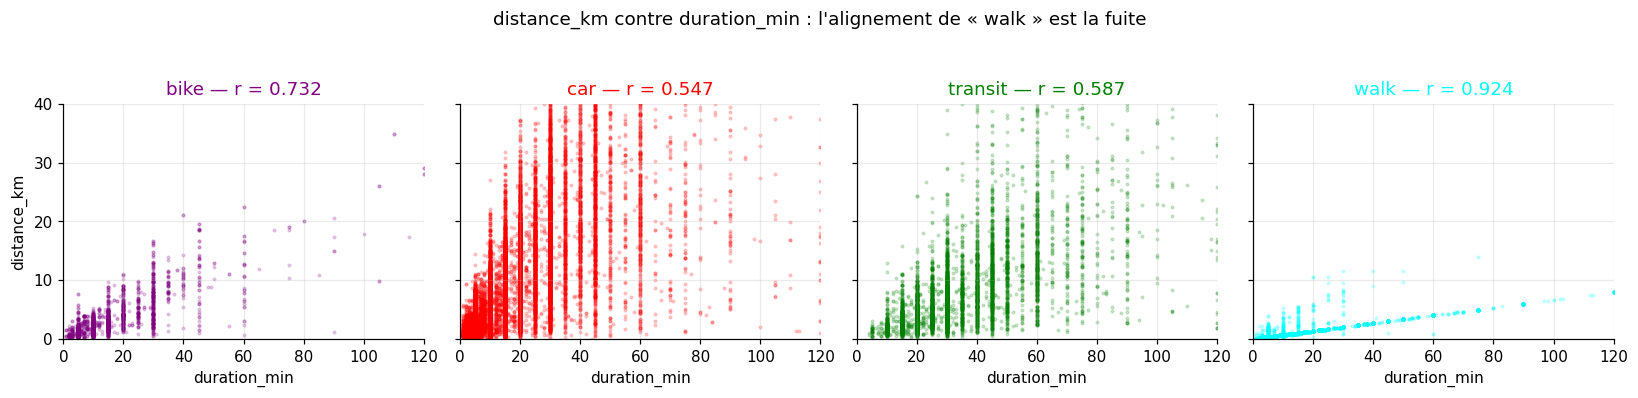

,duration_min,crow_km,od_km
mode,,,
bike,0.732,0.972,0.960
car,0.547,0.979,0.974
transit,0.587,0.997,0.966
walk,0.924,0.993,0.412


✅ aucune colonne contaminée dans le contrat de features


In [18]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 3.4), sharey=True)
for ax, cls in zip(axes, CLASSES):
    s = full[full["mode"] == cls]
    ax.scatter(s["duration_min"], s["distance_km"], s=3, alpha=0.18, color=MODE_COLORS[cls])
    r = s[["duration_min", "distance_km"]].corr().iloc[0, 1]
    ax.set_title(f"{cls} — r = {r:.3f}", color=MODE_COLORS[cls])
    ax.set_xlabel("duration_min"); ax.set_xlim(0, 120)
axes[0].set_ylabel("distance_km"); axes[0].set_ylim(0, 40)
fig.suptitle("distance_km contre duration_min : l'alignement de « walk » est la fuite", y=1.05)
plt.show()

corr = (full.groupby("mode", observed=True)[["duration_min", "distance_km", "crow_km", "od_km"]]
        .corr().unstack()["distance_km"][["duration_min", "crow_km", "od_km"]])
display(corr.round(3))

fuite_entrainee = [c for c in LEAKY if c in FEATURES]
print("✅ aucune colonne contaminée dans le contrat de features"
      if not fuite_entrainee else f"🚨 [ALARME] contaminées dans les features : {fuite_entrainee}")

---## 7. Ce que chaque variable dit de la cibleParts modales **redressées** par tranche. C'est la lecture qui compte : le modèle estnoté sur des parts de population, pas sur des effectifs d'échantillon.

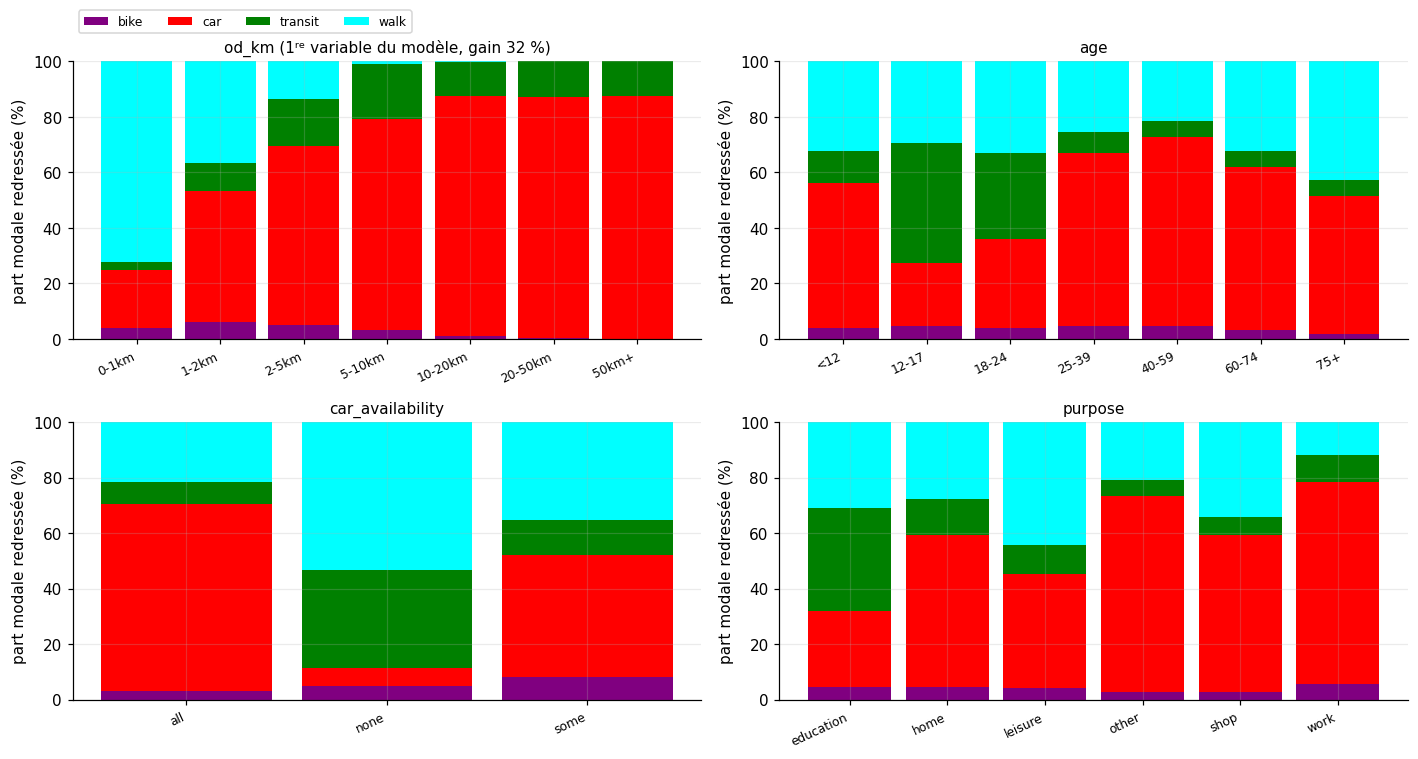

Parts modales redressées par tranche de od_km (%) :


mode,bike,car,transit,walk
od_km,,,,
0-1km,3.900,21.100,2.800,72.100
1-2km,6.000,47.400,10.100,36.400
2-5km,5.200,64.200,17.000,13.600
5-10km,3.200,76.100,19.800,1.000
10-20km,1.200,86.400,12.300,0.100
20-50km,0.400,86.900,12.700,0.000
50km+,0.000,87.700,12.300,0.000


In [19]:
def parts_par_tranche(df, col, bins=None, labels=None):
    g = pd.cut(df[col].astype(float), bins, labels=labels) if bins is not None else df[col]
    t = df.groupby([g, "mode"], observed=False)["sample_weight"].sum().unstack("mode")
    return (100 * t.div(t.sum(axis=1), axis=0)).reindex(columns=CLASSES), t.sum(axis=1)

def barres_empilees(ax, parts, effectif, titre):
    bas = np.zeros(len(parts))
    for cls in CLASSES:
        v = parts[cls].fillna(0).values
        ax.bar(range(len(parts)), v, bottom=bas, color=MODE_COLORS[cls], label=cls, width=0.85)
        bas += v
    ax.set_xticks(range(len(parts)), [str(i)[:18] for i in parts.index], rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 100); ax.set_title(titre, fontsize=10); ax.set_ylabel("part modale redressée (%)")

BORNES = [0, 1, 2, 5, 10, 20, 50, 1e4]
ETIQ = ["0-1km", "1-2km", "2-5km", "5-10km", "10-20km", "20-50km", "50km+"]
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
p, e = parts_par_tranche(full, "od_km", BORNES, ETIQ); barres_empilees(axes[0, 0], p, e, "od_km (1ʳᵉ variable du modèle, gain 32 %)")
p, e = parts_par_tranche(full, "age", [0, 12, 18, 25, 40, 60, 75, 130],
                         ["<12", "12-17", "18-24", "25-39", "40-59", "60-74", "75+"])
barres_empilees(axes[0, 1], p, e, "age")
p, e = parts_par_tranche(full, "car_availability"); barres_empilees(axes[1, 0], p, e, "car_availability")
p, e = parts_par_tranche(full, "purpose"); barres_empilees(axes[1, 1], p, e, "purpose")
axes[0, 0].legend(ncols=4, fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.08))
plt.show()

print("Parts modales redressées par tranche de od_km (%) :")
display(parts_par_tranche(full, "od_km", BORNES, ETIQ)[0].round(1))

### Effectif de test par croisement mode × distanceLe chiffre qui décide de ce qu'on a le droit de conclure. Une case à quelques unités nesupporte aucune lecture : c'est exactement le mécanisme qui fait qu'**une tranche dedistance à un seul déplacement pèse autant qu'une tranche à 856** dans l'EMD ordinale dela page de synthèse. Ici on le voit avant de scorer.

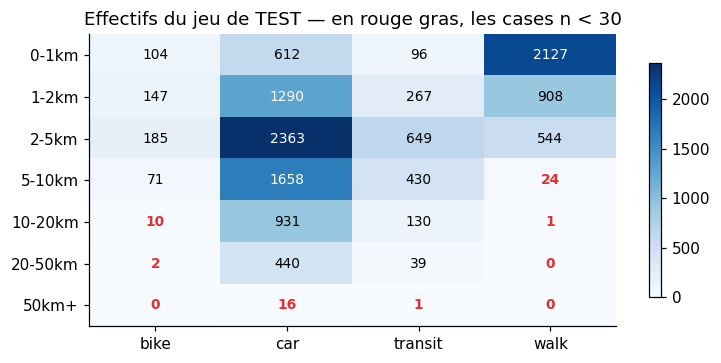

9 cases sous 30 observations : [('5-10km', 'walk', 24), ('10-20km', 'bike', 10), ('10-20km', 'walk', 1), ('20-50km', 'bike', 2), ('20-50km', 'walk', 0), ('50km+', 'bike', 0), ('50km+', 'car', 16), ('50km+', 'transit', 1), ('50km+', 'walk', 0)]


In [20]:
cell = pd.crosstab(pd.cut(test["od_km"].astype(float), BORNES, labels=ETIQ),
                   test["mode"]).reindex(columns=CLASSES).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7, 3.4))
im = ax.imshow(cell.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(CLASSES)), CLASSES); ax.set_yticks(range(len(cell)), cell.index)
for i in range(cell.shape[0]):
    for j in range(cell.shape[1]):
        v = cell.values[i, j]
        ax.text(j, i, v, ha="center", va="center", fontsize=9,
                color=("#E03131" if v < 30 else ("white" if v > cell.values.max()/2 else "black")),
                fontweight=("bold" if v < 30 else "normal"))
ax.set_title("Effectifs du jeu de TEST — en rouge gras, les cases n < 30")
fig.colorbar(im, ax=ax, shrink=0.8); ax.grid(False)
plt.show()
maigres = [(i, c, int(cell.loc[i, c])) for i in cell.index for c in CLASSES if cell.loc[i, c] < 30]
print(f"{len(maigres)} cases sous 30 observations : {maigres}")

---## 8. Corrélations entre variables numériquesDeux variables quasi identiques ne cassent pas un booster — elles se partagent le gain,ce qui **dilue l'importance des variables** et rend l'attribution trompeuse. Le repère àretenir avant de lire un classement de `feature_importance`.

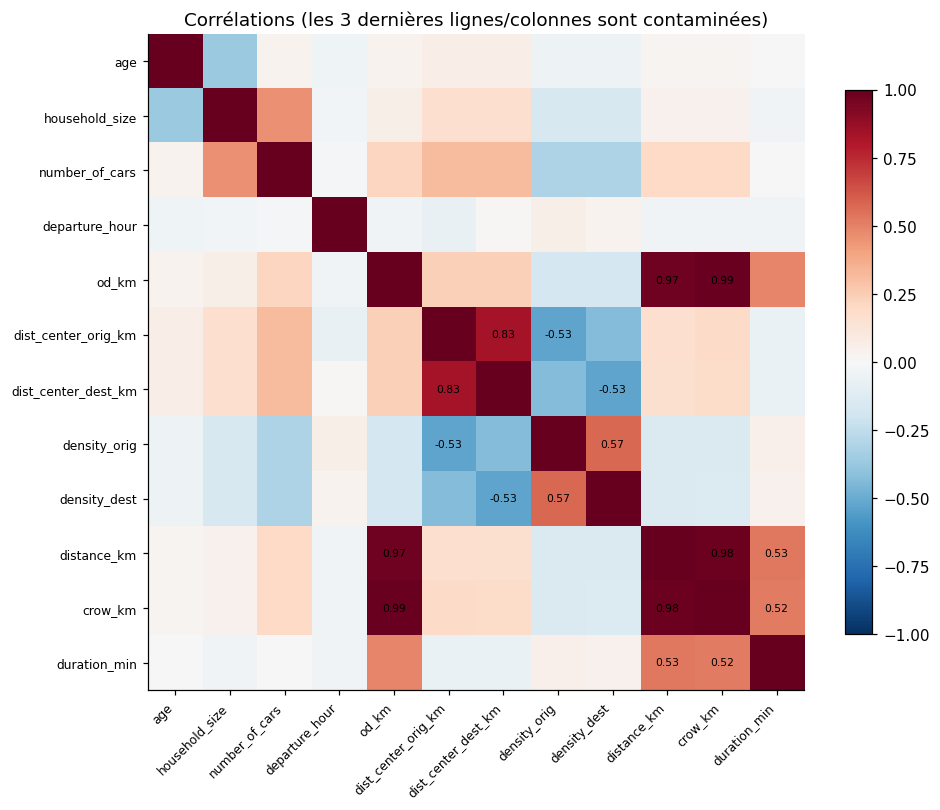

Paires |r| > 0,6 : [('od_km', 'distance_km', np.float64(0.972)), ('od_km', 'crow_km', np.float64(0.989)), ('dist_center_orig_km', 'dist_center_dest_km', np.float64(0.83)), ('distance_km', 'crow_km', np.float64(0.983))]


In [21]:
cols = NUMERIC + LEAKY
c = full[cols].astype(float).corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(cols)), cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        if i != j and abs(c.iloc[i, j]) > 0.5:
            ax.text(j, i, f"{c.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Corrélations (les 3 dernières lignes/colonnes sont contaminées)")
plt.show()

paires = [(cols[i], cols[j], round(c.iloc[i, j], 3))
          for i in range(len(cols)) for j in range(i + 1, len(cols)) if abs(c.iloc[i, j]) > 0.6]
print("Paires |r| > 0,6 :", paires or "aucune")

---## 9. Synthèse des drapeauxCe que ce notebook a effectivement vérifié, et le verdict de chaque contrôle. Un tableauvide de ⚠ ne dit pas que le jeu est parfait : il dit que **ces** contrôles-là passent.

In [22]:
flags = [
    ("découpage étanche au ménage", len(fuite) == 0, f"{len(fuite)} ménages à cheval"),
    ("part de test conforme au spec",
     abs(len(test)/len(full) - SPEC["split"]["test_size"]) < 0.02,
     f"{len(test)/len(full):.1%} contre {SPEC['split']['test_size']:.0%} attendus"),
    ("aucune colonne contaminée entraînée", not fuite_entrainee, str(fuite_entrainee)),
    ("représentativité numérique (SMD ≤ 0,25)",
     bool((rep_num["SMD"].fillna(0) <= 0.25).all()),
     f"max {rep_num['SMD'].max():.3f} sur « {rep_num['SMD'].idxmax()} »"),
    ("représentativité catégorielle (TVD ≤ 3 pts)",
     bool((rep_cat.iloc[:, 0] <= 3).all()),
     f"max {rep_cat.iloc[:, 0].max():.2f} pts sur « {rep_cat.iloc[:, 0].idxmax()} »"),
    ("aucune impossibilité de domaine", bool((impo["n"] == 0).all()),
     f"{int(impo['n'].sum())} lignes sur {len(impo)} règles"),
    ("aucune saturation sur une variable RETENUE", suspect[~suspect["contaminée"]].empty,
     ", ".join(suspect.index) + " (toutes contaminées)" if not suspect.empty else "—"),
    ("aucune case test mode × distance sous 30", len(maigres) == 0, f"{len(maigres)} cases maigres"),
    ("poids de redressement tous > 0", bool((full['sample_weight'] > 0).all()), ""),
]
synth = pd.DataFrame(flags, columns=["contrôle", "ok", "détail"])
synth["verdict"] = np.where(synth["ok"], "✅", "⚠")
display(synth[["contrôle", "verdict", "détail"]])
ko = synth[~synth["ok"]]
print(f"\n{len(ko)} contrôle(s) en défaut." if len(ko) else "\nTous les contrôles passent.")

,contrôle,verdict,détail
0,découpage étanche au ménage,✅,0 ménages à cheval
1,part de test conforme au spec,✅,25.0% contre 25% attendus
2,aucune colonne contaminée entraînée,✅,[]
3,"représentativité numérique (SMD ≤ 0,25)",✅,max 0.037 sur « household_size »
4,représentativité catégorielle (TVD ≤ 3 pts),✅,max 2.55 pts sur « socioprofessional_class »
5,aucune impossibilité de domaine,✅,0 lignes sur 10 règles
6,aucune saturation sur une variable RETENUE,✅,"duration_min, distance_km, crow_km (toutes con..."
7,aucune case test mode × distance sous 30,⚠,9 cases maigres
8,poids de redressement tous > 0,✅,



1 contrôle(s) en défaut.
